<a href="https://colab.research.google.com/github/Aman3710/VOIS-data-analysis/blob/main/VOIS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Loading & Understanding


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 30)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

df = pd.read_csv('dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSeasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Seasons: ['Kharif' 'Rabi' 'Zaid']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Irrigation methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 2. Data Cleaning & Preparation

In [ ]:
# Impute missing values within each Crop group (crop-specific median)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Crop')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())

# Standardize categorical text
for c in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df[c] = df[c].astype(str).str.strip().str.title()

# Sanity checks: no negative physical quantities
neg_check = (df[['Rainfall_mm','Yield_Tonnes_Ha','Total_Cost_INR','Revenue_INR',
                  'Water_Used_m3','Farm_Area_Hectares']] < 0).sum()
print("\nNegative-value check (should be all 0):")
print(neg_check)

# Order seasons in agronomic calendar order for consistent plotting
season_order = ['Zaid', 'Kharif', 'Rabi']
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)

print("\nFinal cleaned shape:", df.shape)

Remaining missing values: 0

Negative-value check (should be all 0):
Rainfall_mm           0
Yield_Tonnes_Ha       0
Total_Cost_INR        0
Revenue_INR           0
Water_Used_m3         0
Farm_Area_Hectares    0
dtype: int64

Final cleaned shape: (4000, 28)


Checking missing values again to confirm

In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Series([], dtype: int64)


## 3. Seasonal Performance Comparison

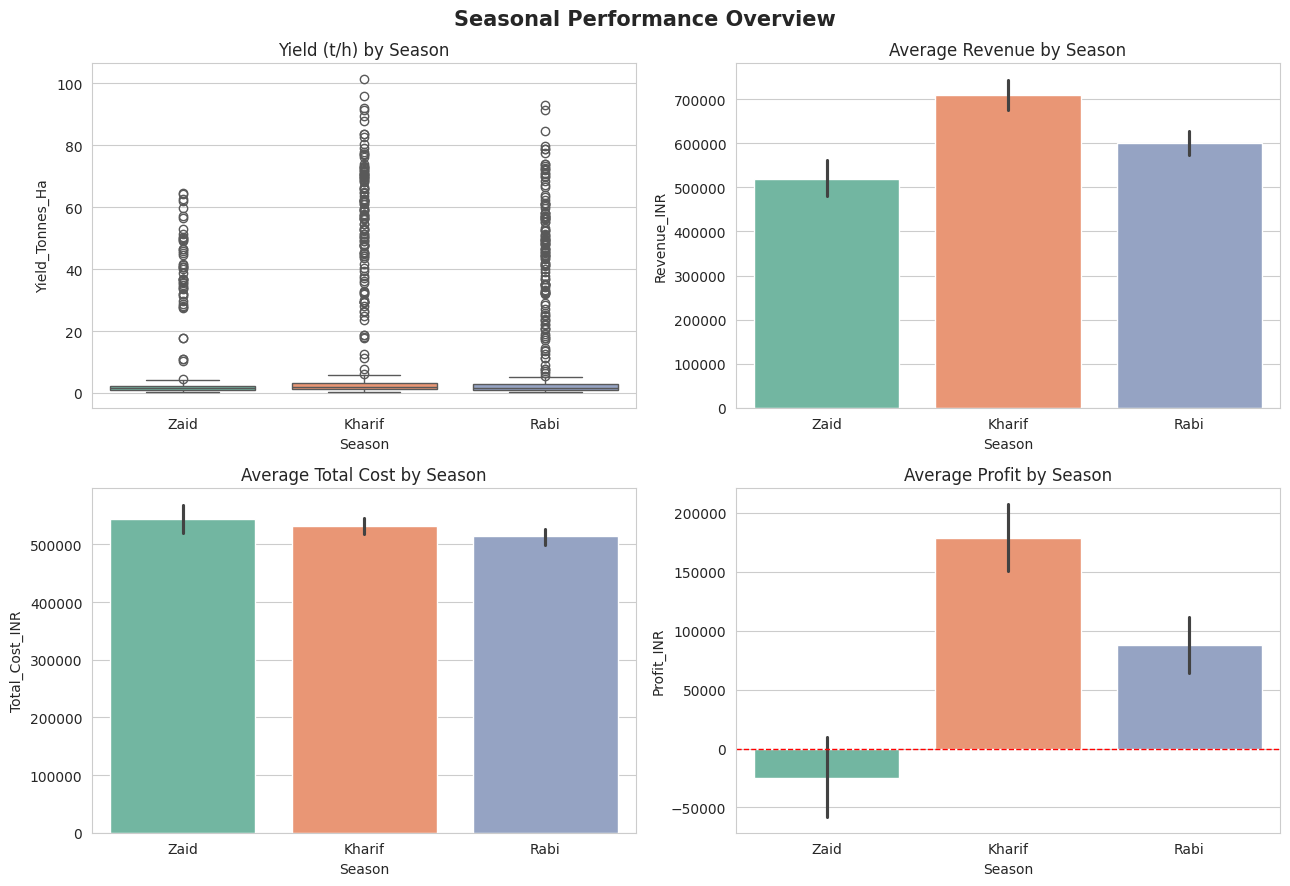

In [ ]:
perf_metrics = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR','Revenue_INR', 'Profit_INR']
season_summary = df.groupby('Season', observed=True)[perf_metrics].agg(['mean', 'median'])
season_summary.round(1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Yield (t/h) by Season')

sns.barplot(data=df, x='Season', y='Revenue_INR', ax=axes[0,1], estimator=np.mean,
            errorbar=('ci', 95), palette='Set2')
axes[0,1].set_title('Average Revenue by Season')

sns.barplot(data=df, x='Season', y='Total_Cost_INR', ax=axes[1,0], estimator=np.mean,
            errorbar=('ci', 95), palette='Set2')
axes[1,0].set_title('Average Total Cost by Season')

sns.barplot(data=df, x='Season', y='Profit_INR', ax=axes[1,1], estimator=np.mean,
            errorbar=('ci', 95), palette='Set2')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_title('Average Profit by Season')

plt.suptitle('Seasonal Performance Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('seasonal_Perf_overview.png', dpi=150)
plt.show()

In [ ]:
best_yield_season = df.groupby('Season', observed=True)['Yield_Tonnes_Ha'].mean().idxmax()
best_profit_season = df.groupby('Season', observed=True)['Profit_INR'].mean().idxmax()
worst_profit_season = df.groupby('Season', observed=True)['Profit_INR'].mean().idxmin()

print(f"Highest average yield season   : {best_yield_season}")
print(f"Most profitable season (avg)   : {best_profit_season}")
print(f"Least profitable season (avg)  : {worst_profit_season}")

profit_pct_negative = df.groupby('Season', observed=True)['Profit_INR'].apply(lambda x: (x < 0).mean() * 100)
print("\n% of farms operating at a loss, by season:")
print(profit_pct_negative.round(1))

Highest average yield season   : Kharif
Most profitable season (avg)   : Kharif
Least profitable season (avg)  : Zaid

% of farms operating at a loss, by season:
Season
Zaid      64.5
Kharif    42.2
Rabi      51.1
Name: Profit_INR, dtype: float64


## 4. Statistical Significance Testing (ANOVA)

In [ ]:
anova_results = []
for metric in perf_metrics:
    groups = [df.loc[df['Season'] == s, metric].dropna() for s in season_order]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({'Metric': metric, 'F-statistic': round(f_stat, 2),
                           'p-value': round(p_val, 5),
                           'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No'})

anova_df = pd.DataFrame(anova_results)
anova_df

,Metric,F-statistic,p-value,Significant (p<0.05)
0,Yield_Tonnes_Ha,1.44,0.23686,No
1,Production_Tonnes,1.03,0.35845,No
2,Total_Cost_INR,2.84,0.05843,No
3,Revenue_INR,24.89,0.00000,Yes
4,Profit_INR,34.29,0.00000,Yes


## 5. Environmental Conditions Across Seasons

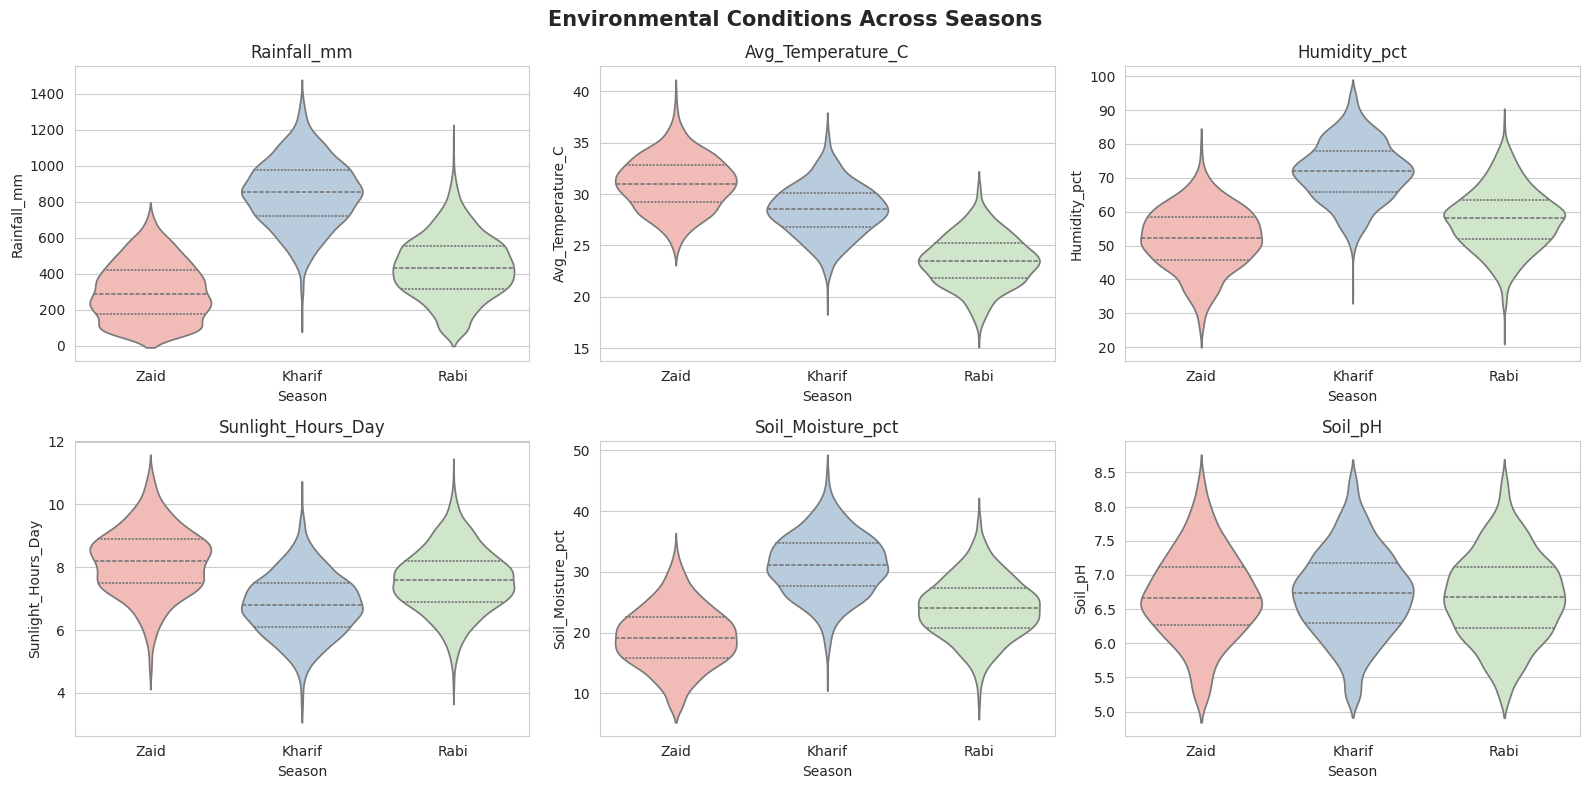

In [ ]:
env_metrics = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
               'Sunlight_Hours_Day', 'Soil_Moisture_pct', 'Soil_pH']

env_summary = df.groupby('Season', observed=True)[env_metrics].mean().round(2)
env_summary


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, metric in zip(axes.flatten(), env_metrics):
    sns.violinplot(data=df, x='Season', y=metric, ax=ax, palette='Pastel1', inner='quartile')
    ax.set_title(metric)
plt.suptitle('Environmental Conditions Across Seasons', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig02_environmental_conditions.png', dpi=150)
plt.show()

## 6. Resource Usage & Efficiency Across Seasons

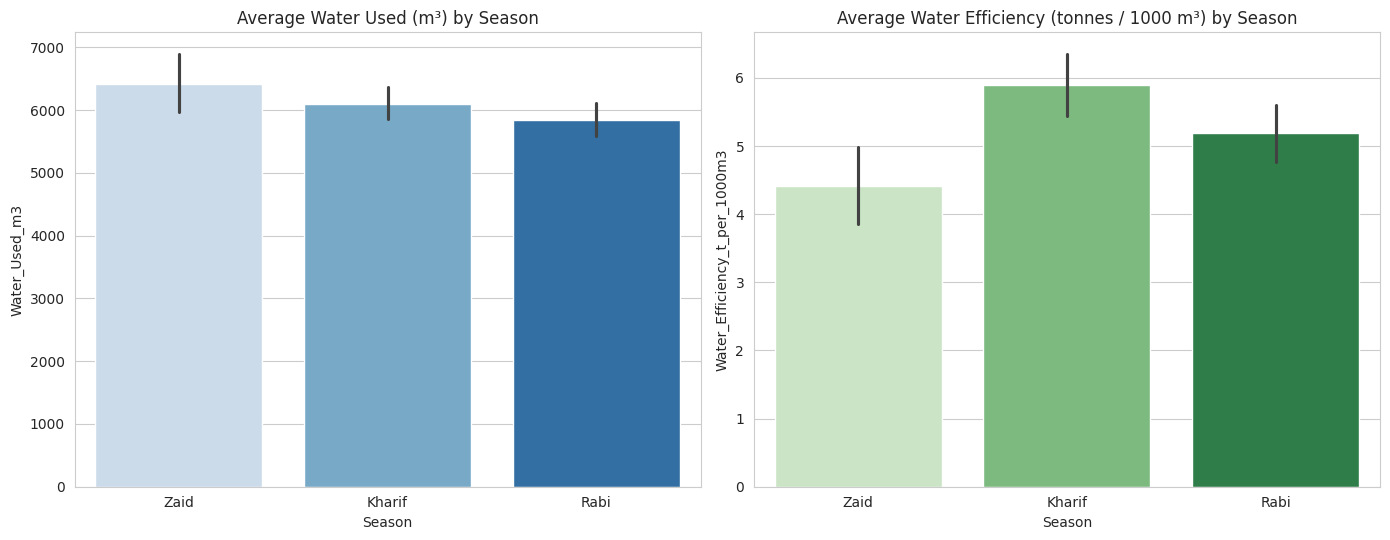

In [ ]:
resource_metrics = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
                     'Water_Efficiency_t_per_1000m3']
resource_summary = df.groupby('Season', observed=True)[resource_metrics].mean().round(2)
resource_summary

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.barplot(data=df, x='Season', y='Water_Used_m3', ax=axes[0], estimator=np.mean, palette='Blues')
axes[0].set_title('Average Water Used (m³) by Season')

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1],
            estimator=np.mean, palette='Greens')
axes[1].set_title('Average Water Efficiency (tonnes / 1000 m³) by Season')

plt.tight_layout()
plt.savefig('fig03_water_usage_efficiency.png', dpi=150)
plt.show()

In [ ]:
irrigation_by_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
print("Irrigation method mix by season (% of farms):")
irrigation_by_season.round(1)

Irrigation method mix by season (% of farms):


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Zaid,23.6,32.7,23.6,20.2
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0


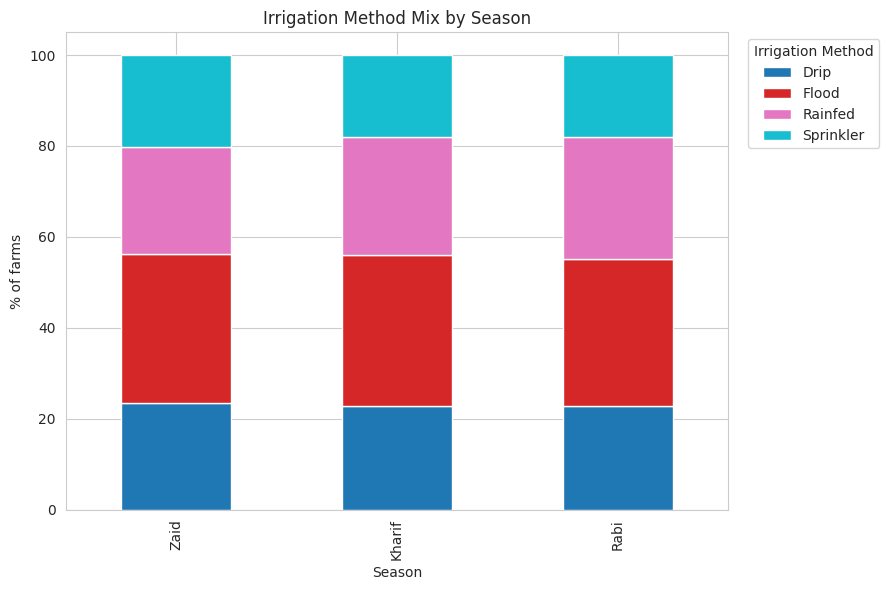

In [ ]:
irrigation_by_season.plot(kind='bar', stacked=True, figsize=(9,6), colormap='tab10')
plt.title('Irrigation Method Mix by Season')
plt.ylabel('% of farms')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig04_irrigation_mix.png', dpi=150)
plt.show()

## 7. Relationships Between Environmental Conditions and Performance

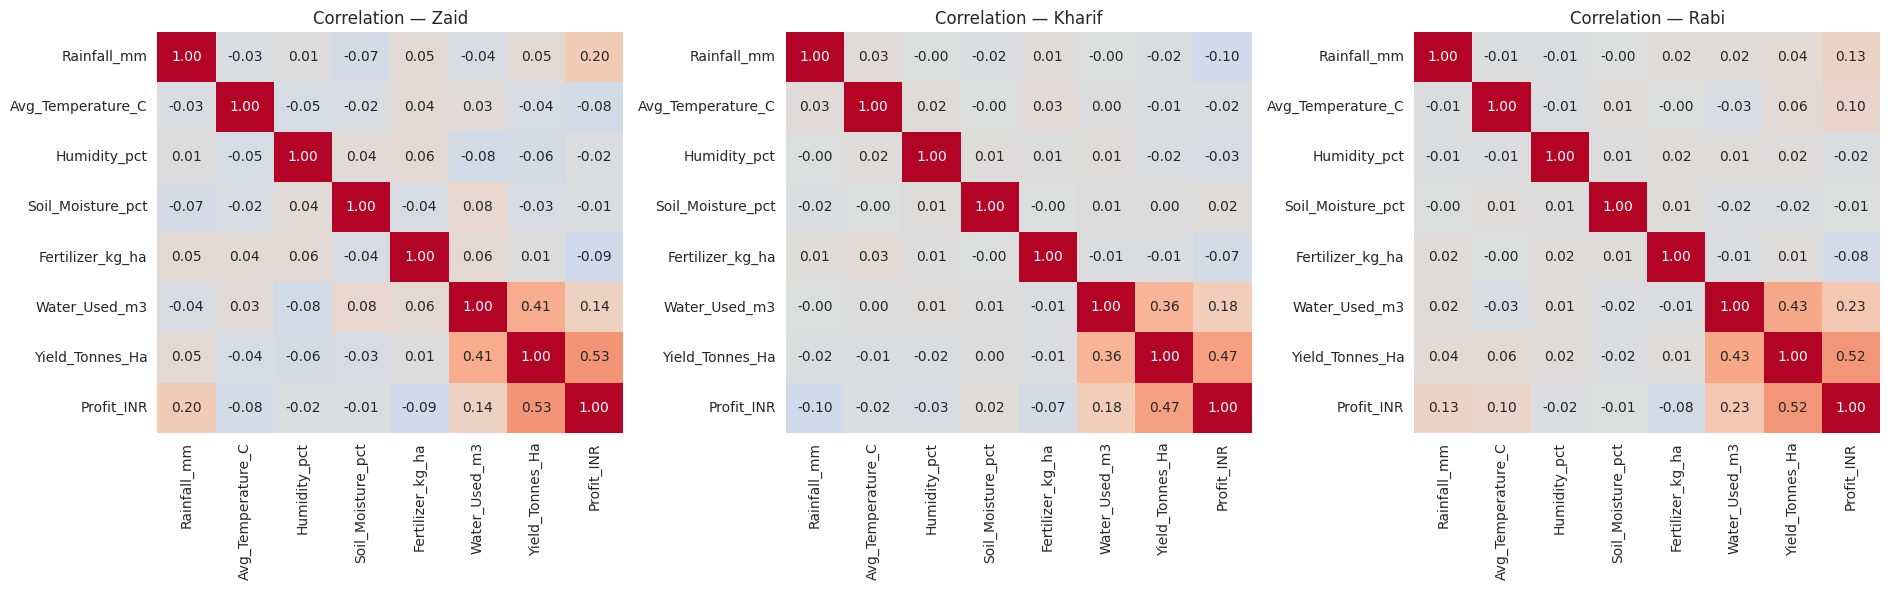

In [ ]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR']

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, s in zip(axes, season_order):
    sub = df[df['Season'] == s][corr_cols]
    sns.heatmap(sub.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, cbar=False, vmin=-1, vmax=1)
    ax.set_title(f'Correlation — {s}')
plt.tight_layout()
plt.savefig('fig05_correlation_by_season.png', dpi=150)
plt.show()

In [ ]:
# Overall correlation of Yield with each environmental factor, per season
print("Correlation of Yield_Tonnes_Ha with environmental factors, by season:\n")
for s in season_order:
    sub = df[df['Season'] == s]
    corrs = sub[['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct']].corrwith(sub['Yield_Tonnes_Ha'])
    print(f"--- {s} ---")
    print(corrs.round(3))
    print()

Correlation of Yield_Tonnes_Ha with environmental factors, by season:

--- Zaid ---
Rainfall_mm          0.050
Avg_Temperature_C   -0.044
Humidity_pct        -0.061
Soil_Moisture_pct   -0.031
dtype: float64

--- Kharif ---
Rainfall_mm         -0.016
Avg_Temperature_C   -0.011
Humidity_pct        -0.016
Soil_Moisture_pct    0.000
dtype: float64

--- Rabi ---
Rainfall_mm          0.039
Avg_Temperature_C    0.057
Humidity_pct         0.015
Soil_Moisture_pct   -0.018
dtype: float64



## 8. Are Seasonal Patterns Consistent Across States?

In [ ]:
state_season_yield = df.groupby(['State', 'Season'], observed=True)['Yield_Tonnes_Ha'].mean().unstack()
state_season_yield.round(2)

Season,Zaid,Kharif,Rabi
State,,,
Andhra Pradesh,4.45,5.68,3.47
Gujarat,4.08,6.34,5.68
Karnataka,6.62,6.45,4.79
Madhya Pradesh,5.47,5.99,3.76
Maharashtra,2.27,5.43,5.50
Punjab,5.91,4.10,8.61
Tamil Nadu,4.10,5.52,4.50
Telangana,4.25,5.55,4.80


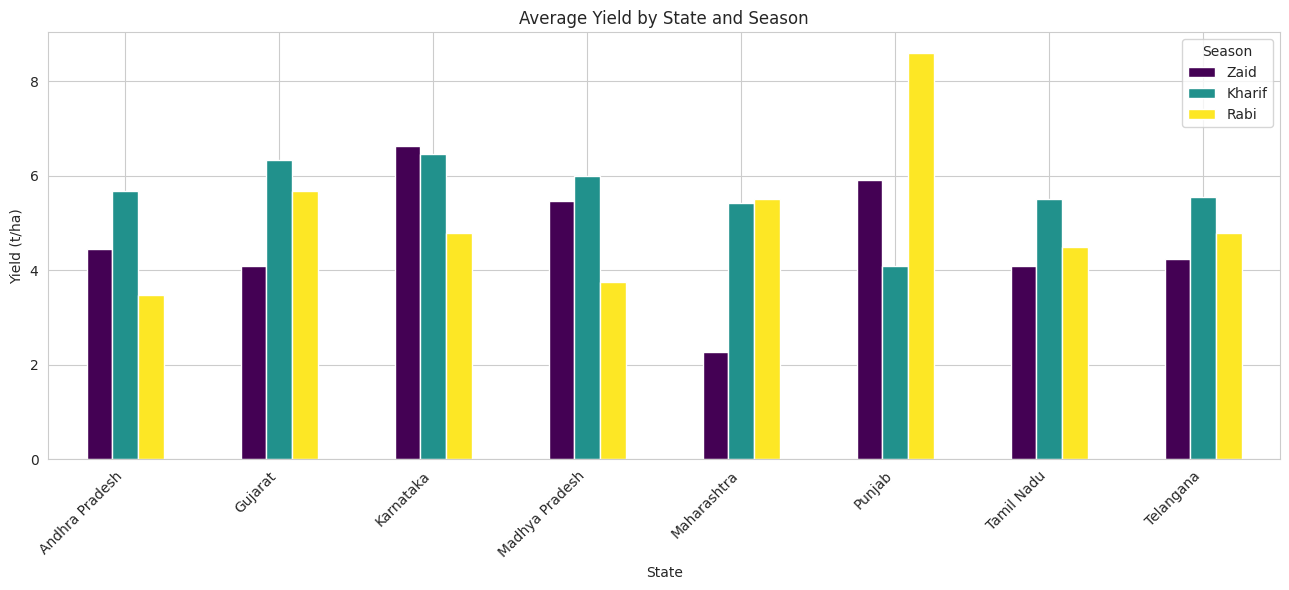

In [ ]:
state_season_yield.plot(kind='bar', figsize=(13, 6), colormap='viridis')
plt.title('Average Yield by State and Season')
plt.ylabel('Yield (t/ha)')
plt.legend(title='Season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs_imagesfig06_state_season_yield.png', dpi=150)
plt.show()

In [ ]:
best_season_per_state = state_season_yield.idxmax(axis=1)
print("Best-yielding season per state:")
print(best_season_per_state)
print("\nConsistency check — how many states share the overall best season:")
print(best_season_per_state.value_counts())

Best-yielding season per state:
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka           Zaid
Madhya Pradesh    Kharif
Maharashtra         Rabi
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: category
Categories (3, object): ['Zaid' < 'Kharif' < 'Rabi']

Consistency check — how many states share the overall best season:
Kharif    5
Rabi      2
Zaid      1
Name: count, dtype: int64


## 9. Outlier & Unusual Pattern Detection

In [ ]:
def flag_outliers(g):
    z = np.abs(stats.zscore(g['Yield_Tonnes_Ha']))
    return g.assign(Yield_Zscore=z, Is_Outlier=z > 2.5)

df_flagged = df.groupby('Crop', group_keys=False)[df.columns].apply(flag_outliers)
n_outliers = df_flagged['Is_Outlier'].sum()
print(f"Unusual yield records flagged (|z|>2.5, within-crop): {n_outliers} "
      f"({n_outliers/len(df_flagged)*100:.1f}% of records)")

print("\nOutliers by season:")
print(df_flagged[df_flagged['Is_Outlier']]['Season'].value_counts())

print("\nOutliers by crop:")
print(df_flagged[df_flagged['Is_Outlier']]['Crop'].value_counts())


Unusual yield records flagged (|z|>2.5, within-crop): 13 (0.3% of records)

Outliers by season:
Season
Kharif    12
Rabi       1
Zaid       0
Name: count, dtype: int64

Outliers by crop:
Crop
Pulses       3
Groundnut    2
Rice         2
Maize        2
Wheat        1
Sugarcane    1
Chilli       1
Cotton       1
Name: count, dtype: int64


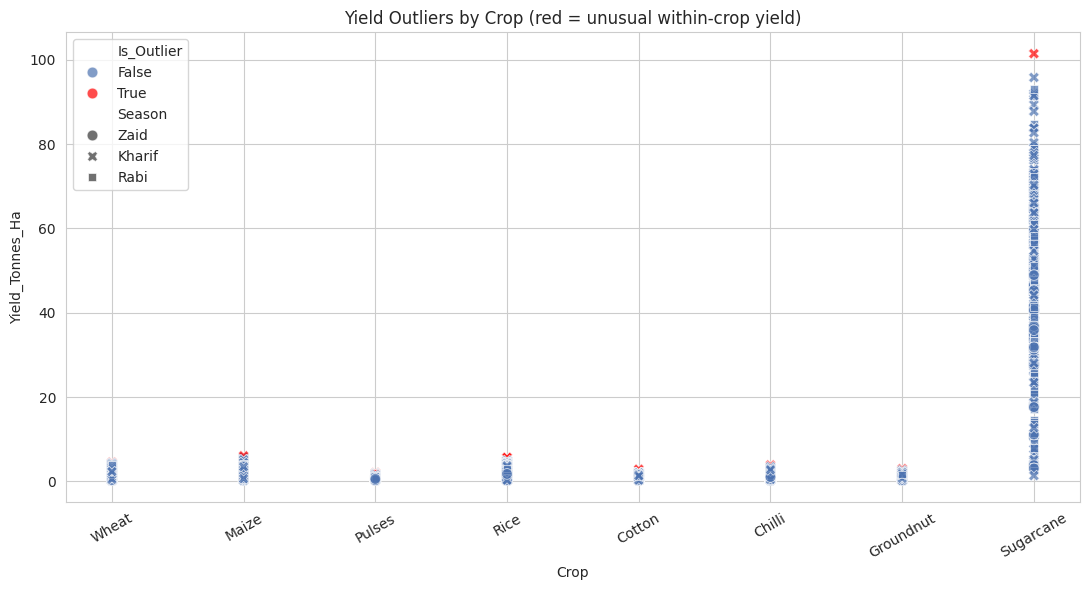

In [ ]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df_flagged, x='Crop', y='Yield_Tonnes_Ha', hue='Is_Outlier',
                 style='Season', palette={True:'red', False:'#4C72B0'}, s=60, alpha=0.7)
plt.title('Yield Outliers by Crop (red = unusual within-crop yield)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig07_yield_outliers.png', dpi=150)
plt.show()
